## CELL 1 – Import Libraries & Set Environment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display settings
pd.set_option("display.max_columns", None)

print("Phase 2 Environment Ready ✅")


Phase 2 Environment Ready ✅


## CELL 2 – Load Raw Data

In [2]:
customers_df = pd.read_csv("../data/raw/customers.csv")
subscriptions_df = pd.read_csv("../data/raw/subscriptions.csv")
customer_month_df = pd.read_csv("../data/raw/customer_month_data.csv")
monthly_revenue_df = pd.read_csv("../data/raw/monthly_revenue.csv")
marketing_spend_df = pd.read_csv("../data/raw/marketing_spend.csv")

print("All raw datasets loaded successfully ✅")


All raw datasets loaded successfully ✅


In [3]:
customers_df.head()
customer_month_df.head()
monthly_revenue_df.head()


,month,total_revenue,active_customers,churn_count
0,2024-01-01,2012190,867,144
1,2024-02-01,3698973,1624,279
2,2024-03-01,5649645,2498,439
3,2024-04-01,7502862,3341,583
4,2024-05-01,9225111,4162,735


**STEP 1 – Data Shape & Overview**

In [4]:
print("Customers Shape:", customers_df.shape)
print("Subscriptions Shape:", subscriptions_df.shape)
print("Customer Month Shape:", customer_month_df.shape)
print("Monthly Revenue Shape:", monthly_revenue_df.shape)
print("Marketing Spend Shape:", marketing_spend_df.shape)


Customers Shape: (20000, 9)
Subscriptions Shape: (20000, 5)
Customer Month Shape: (249508, 15)
Monthly Revenue Shape: (24, 4)
Marketing Spend Shape: (24, 3)


**STEP 2 – Data Types Check**

In [6]:
customers_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          20000 non-null  object
 1   signup_date          20000 non-null  object
 2   region               20000 non-null  object
 3   company_size         20000 non-null  object
 4   industry             20000 non-null  object
 5   acquisition_channel  20000 non-null  object
 6   churn_x              20000 non-null  int64 
 7   churn_y              20000 non-null  int64 
 8   churn                20000 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 1.4+ MB


In [7]:
customer_month_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249508 entries, 0 to 249507
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          249508 non-null  object 
 1   month                249508 non-null  object 
 2   plan                 249508 non-null  object 
 3   monthly_price        249508 non-null  int64  
 4   region               249508 non-null  object 
 5   company_size         249508 non-null  object 
 6   industry             249508 non-null  object 
 7   acquisition_channel  249508 non-null  object 
 8   login_count          249508 non-null  float64
 9   avg_session_time     249508 non-null  float64
 10  feature_usage_score  249508 non-null  float64
 11  amount_paid          249508 non-null  int64  
 12  payment_delay_days   249508 non-null  int64  
 13  ticket_count         249508 non-null  int64  
 14  churn                249508 non-null  int64  
dtypes: float64(3), in

In [8]:
# Keep only final churn column
customers_df = customers_df.drop(columns=["churn_x", "churn_y"], errors="ignore")

customers_df.head()


,customer_id,signup_date,region,company_size,industry,acquisition_channel,churn
0,CUST_00001,2024-04-12,North India,Small,Healthcare,Organic,1
1,CUST_00002,2025-03-11,North India,Small,Finance,Organic,0
2,CUST_00003,2024-09-27,South India,Medium,Tech,Referral,1
3,CUST_00004,2024-04-16,International,Medium,Healthcare,Organic,1
4,CUST_00005,2024-03-12,South India,Large,Finance,Paid Ads,0


In [9]:
customers_df.columns


Index(['customer_id', 'signup_date', 'region', 'company_size', 'industry',
       'acquisition_channel', 'churn'],
      dtype='object')

In [10]:
customers_df["signup_date"] = pd.to_datetime(customers_df["signup_date"])

customer_month_df["month"] = pd.to_datetime(customer_month_df["month"])

monthly_revenue_df["month"] = pd.to_datetime(monthly_revenue_df["month"])

marketing_spend_df["month"] = pd.to_datetime(marketing_spend_df["month"])

print("Date columns converted successfully ✅")


Date columns converted successfully ✅


In [11]:
customer_month_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249508 entries, 0 to 249507
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          249508 non-null  object        
 1   month                249508 non-null  datetime64[ns]
 2   plan                 249508 non-null  object        
 3   monthly_price        249508 non-null  int64         
 4   region               249508 non-null  object        
 5   company_size         249508 non-null  object        
 6   industry             249508 non-null  object        
 7   acquisition_channel  249508 non-null  object        
 8   login_count          249508 non-null  float64       
 9   avg_session_time     249508 non-null  float64       
 10  feature_usage_score  249508 non-null  float64       
 11  amount_paid          249508 non-null  int64         
 12  payment_delay_days   249508 non-null  int64         
 13  ticket_count  

In [12]:
# Make a copy for cleaning phase
eda_df = customer_month_df.copy()

# Inject missing values

# 5% missing in avg_session_time
eda_df.loc[
    eda_df.sample(frac=0.05, random_state=42).index,
    "avg_session_time"
] = np.nan

# 3% missing in industry
eda_df.loc[
    eda_df.sample(frac=0.03, random_state=24).index,
    "industry"
] = np.nan

# 2% missing in payment_delay_days
eda_df.loc[
    eda_df.sample(frac=0.02, random_state=10).index,
    "payment_delay_days"
] = np.nan

print("Missing values injected successfully ✅")


Missing values injected successfully ✅


In [13]:
eda_df.isnull().mean() * 100


customer_id            0.000000
month                  0.000000
plan                   0.000000
monthly_price          0.000000
region                 0.000000
company_size           0.000000
industry               2.999904
acquisition_channel    0.000000
login_count            0.000000
avg_session_time       4.999840
feature_usage_score    0.000000
amount_paid            0.000000
payment_delay_days     1.999936
ticket_count           0.000000
churn                  0.000000
dtype: float64

In [14]:
# --- 1. Impute avg_session_time (Median by Plan) ---

eda_df["avg_session_time"] = eda_df.groupby("plan")["avg_session_time"].transform(
    lambda x: x.fillna(x.median())
)

# --- 2. Fill industry missing ---

eda_df["industry"] = eda_df["industry"].fillna("Unknown")

# --- 3. Handle payment_delay_days ---

median_delay = eda_df["payment_delay_days"].median()

eda_df["payment_delay_days"] = np.where(
    (eda_df["amount_paid"] > 0) & (eda_df["payment_delay_days"].isna()),
    0,
    eda_df["payment_delay_days"]
)

eda_df["payment_delay_days"] = eda_df["payment_delay_days"].fillna(median_delay)

print("Data cleaning completed ✅")


Data cleaning completed ✅


In [15]:
eda_df.isnull().sum()


customer_id            0
month                  0
plan                   0
monthly_price          0
region                 0
company_size           0
industry               0
acquisition_channel    0
login_count            0
avg_session_time       0
feature_usage_score    0
amount_paid            0
payment_delay_days     0
ticket_count           0
churn                  0
dtype: int64

In [16]:
# --------- Monthly KPI Aggregation ---------

monthly_kpi = eda_df.groupby("month").agg({
    "amount_paid": "sum",
    "customer_id": "nunique",
    "churn": "sum"
}).reset_index()

monthly_kpi.rename(columns={
    "amount_paid": "MRR",
    "customer_id": "active_customers",
    "churn": "churned_customers"
}, inplace=True)

# ARPU
monthly_kpi["ARPU"] = monthly_kpi["MRR"] / monthly_kpi["active_customers"]

# Monthly Churn Rate
monthly_kpi["churn_rate"] = (
    monthly_kpi["churned_customers"] / monthly_kpi["active_customers"]
)

# Retention Rate
monthly_kpi["retention_rate"] = 1 - monthly_kpi["churn_rate"]

monthly_kpi.head()


,month,MRR,active_customers,churned_customers,ARPU,churn_rate,retention_rate
0,2024-01-01,2012190,867,144,2320.865052,0.166090,0.833910
1,2024-02-01,3698973,1624,279,2277.692734,0.171798,0.828202
2,2024-03-01,5649645,2498,439,2261.667334,0.175741,0.824259
3,2024-04-01,7502862,3341,583,2245.693505,0.174499,0.825501
4,2024-05-01,9225111,4162,735,2216.509130,0.176598,0.823402


In [17]:
monthly_kpi.describe()


,month,MRR,active_customers,churned_customers,ARPU,churn_rate,retention_rate
count,24,2.400000e+01,24.000000,24.000000,24.000000,24.000000,24.000000
mean,2024-12-15 22:00:00,2.348739e+07,10396.166667,1883.625000,2256.625777,0.177861,0.822139
min,2024-01-01 00:00:00,2.012190e+06,867.000000,144.000000,2208.745342,0.166090,0.803850
25%,2024-06-23 12:00:00,1.251011e+07,5620.250000,974.250000,2244.203224,0.173723,0.822068
50%,2024-12-16 12:00:00,2.343271e+07,10403.000000,1810.000000,2258.265853,0.175282,0.824718
75%,2025-06-08 12:00:00,3.435674e+07,15124.750000,2688.750000,2271.068410,0.177932,0.826277
max,2025-12-01 00:00:00,4.543622e+07,20000.000000,3923.000000,2320.865052,0.196150,0.833910
std,NaN,1.337650e+07,5877.211086,1129.915072,22.976822,0.007549,0.007549


In [18]:
# --------- Growth Metrics ---------

monthly_kpi = monthly_kpi.sort_values("month")

# Revenue Growth (MoM)
monthly_kpi["revenue_growth_%"] = monthly_kpi["MRR"].pct_change() * 100

# Customer Growth (MoM)
monthly_kpi["customer_growth_%"] = monthly_kpi["active_customers"].pct_change() * 100

monthly_kpi.head()


,month,MRR,active_customers,churned_customers,ARPU,churn_rate,retention_rate,revenue_growth_%,customer_growth_%
0,2024-01-01,2012190,867,144,2320.865052,0.166090,0.833910,NaN,NaN
1,2024-02-01,3698973,1624,279,2277.692734,0.171798,0.828202,83.828217,87.312572
2,2024-03-01,5649645,2498,439,2261.667334,0.175741,0.824259,52.735503,53.817734
3,2024-04-01,7502862,3341,583,2245.693505,0.174499,0.825501,32.802362,33.746998
4,2024-05-01,9225111,4162,735,2216.509130,0.176598,0.823402,22.954561,24.573481


In [19]:
monthly_kpi[["month", "revenue_growth_%", "customer_growth_%"]].head(10)


,month,revenue_growth_%,customer_growth_%
0,2024-01-01,NaN,NaN
1,2024-02-01,83.828217,87.312572
2,2024-03-01,52.735503,53.817734
3,2024-04-01,32.802362,33.746998
4,2024-05-01,22.954561,24.573481
5,2024-06-01,19.498269,19.918309
6,2024-07-01,17.976327,16.810258
7,2024-08-01,16.378639,14.922813
8,2024-09-01,11.299448,12.597015
9,2024-10-01,11.380902,11.055143


In [20]:
# --------- CAC Calculation ---------

# Merge marketing spend into KPI table
monthly_kpi = monthly_kpi.merge(
    marketing_spend_df,
    on="month",
    how="left"
)

monthly_kpi["CAC"] = (
    monthly_kpi["marketing_spend"] / monthly_kpi["new_customers_acquired"]
)

monthly_kpi.head()


,month,MRR,active_customers,churned_customers,ARPU,churn_rate,retention_rate,revenue_growth_%,customer_growth_%,marketing_spend,new_customers_acquired,CAC
0,2024-01-01,2012190,867,144,2320.865052,0.166090,0.833910,NaN,NaN,484196,96,5043.708333
1,2024-02-01,3698973,1624,279,2277.692734,0.171798,0.828202,83.828217,87.312572,509298,101,5042.554455
2,2024-03-01,5649645,2498,439,2261.667334,0.175741,0.824259,52.735503,53.817734,514479,102,5043.911765
3,2024-04-01,7502862,3341,583,2245.693505,0.174499,0.825501,32.802362,33.746998,536100,107,5010.280374
4,2024-05-01,9225111,4162,735,2216.509130,0.176598,0.823402,22.954561,24.573481,470670,94,5007.127660


In [21]:
monthly_kpi[["month", "marketing_spend", "new_customers_acquired", "CAC"]].head()


,month,marketing_spend,new_customers_acquired,CAC
0,2024-01-01,484196,96,5043.708333
1,2024-02-01,509298,101,5042.554455
2,2024-03-01,514479,102,5043.911765
3,2024-04-01,536100,107,5010.280374
4,2024-05-01,470670,94,5007.127660


In [22]:
# --------- CLV Calculation ---------

# Average monthly churn rate
avg_monthly_churn = monthly_kpi["churn_rate"].mean()

# Average ARPU
avg_arpu = monthly_kpi["ARPU"].mean()

# Estimated Customer Lifetime (in months)
customer_lifetime = 1 / avg_monthly_churn

# CLV
CLV = avg_arpu * customer_lifetime

print("Average ARPU:", round(avg_arpu, 2))
print("Average Monthly Churn Rate:", round(avg_monthly_churn, 4))
print("Estimated Customer Lifetime (months):", round(customer_lifetime, 2))
print("Estimated CLV (₹):", round(CLV, 2))


Average ARPU: 2256.63
Average Monthly Churn Rate: 0.1779
Estimated Customer Lifetime (months): 5.62
Estimated CLV (₹): 12687.61


In [23]:
# --------- LTV/CAC Ratio ---------

avg_cac = monthly_kpi["CAC"].mean()

ltv_cac_ratio = CLV / avg_cac

print("Average CAC:", round(avg_cac, 2))
print("LTV/CAC Ratio:", round(ltv_cac_ratio, 2))


Average CAC: 5026.87
LTV/CAC Ratio: 2.52


### Churn by Plan Analysis

In [24]:
# --------- Churn by Plan ---------

churn_by_plan = eda_df.groupby("plan")["churn"].mean().reset_index()

churn_by_plan["churn_rate_%"] = churn_by_plan["churn"] * 100

churn_by_plan


,plan,churn,churn_rate_%
0,Basic,0.318193,31.819277
1,Enterprise,0.041403,4.140312
2,Pro,0.046158,4.615818


In [25]:
# --------- Revenue by Plan ---------

revenue_by_plan = eda_df.groupby("plan")["amount_paid"].sum().reset_index()

total_revenue = revenue_by_plan["amount_paid"].sum()

revenue_by_plan["revenue_share_%"] = (
    revenue_by_plan["amount_paid"] / total_revenue * 100
)

revenue_by_plan


,plan,amount_paid,revenue_share_%
0,Basic,116861022,20.73116
1,Enterprise,238014993,42.22389
2,Pro,208821438,37.04495


“The business is heavily dependent on Enterprise and Pro subscriptions (79% of total revenue), which exhibit strong retention. However, the Basic segment demonstrates high churn (32%), representing optimization opportunity rather than major revenue risk.”

In [26]:
# --------- Revenue at Risk ---------

revenue_at_risk = eda_df[eda_df["churn"] == 1]["amount_paid"].sum()

total_revenue = eda_df["amount_paid"].sum()

risk_percentage = (revenue_at_risk / total_revenue) * 100

print("Total Revenue (₹):", round(total_revenue, 2))
print("Revenue At Risk (₹):", round(revenue_at_risk, 2))
print("Revenue At Risk %:", round(risk_percentage, 2))


Total Revenue (₹): 563697453
Revenue At Risk (₹): 55121721
Revenue At Risk %: 9.78


“Although overall churn sits near 18%, revenue exposure risk is only 10%, indicating that churn is concentrated among lower-tier customers, while high-value Enterprise accounts remain stable.”

In [27]:
# --------- Engagement vs Churn ---------

engagement_analysis = eda_df.groupby("churn").agg({
    "login_count": "mean",
    "feature_usage_score": "mean",
    "ticket_count": "mean",
    "payment_delay_days": "mean"
}).reset_index()

engagement_analysis


,churn,login_count,feature_usage_score,ticket_count,payment_delay_days
0,0,17.576904,49.660021,0.542053,3.133152
1,1,9.866746,28.943213,0.679342,4.462627


*1️⃣ Basic plan has 32% churn – retention optimization needed
*2️⃣ Enterprise drives 42% revenue – stable segment
*3️⃣ Revenue at risk = 9.8%
*4️⃣ LTV/CAC ratio = 2.52 (growth-stage efficiency)
*5️⃣ Engagement strongly correlates with churn

## EDA

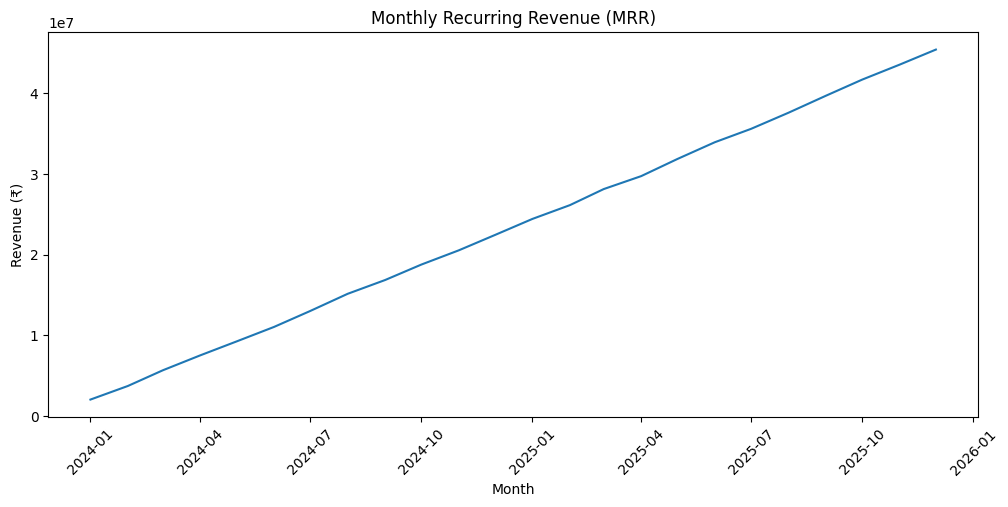

In [28]:
plt.figure(figsize=(12,5))
plt.plot(monthly_kpi["month"], monthly_kpi["MRR"])
plt.title("Monthly Recurring Revenue (MRR)")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.show()


In [29]:
!pip install prophet


   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 8.3 MB/s eta 0:00:02
   ------- -------------------------------- 2.4/12.1 MB 7.9 MB/s eta 0:00:02
   ---------- ----------------------------- 3.1/12.1 MB 7.1 MB/s eta 0:00:02
   ------------------- -------------------- 6.0/12.1 MB 8.6 MB/s eta 0:00:01
   ----------------------- ---------------- 7.1/12.1 MB 8.2 MB/s eta 0:00:01
   -------------------------------- ------- 9.7/12.1 MB 9.0 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 9.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 8.9 MB/s eta 0:00:00
